In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
!apt-get update -qq
!apt-get install -y fonts-nanum -qq

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
fontprop = fm.FontProperties(fname=font_path)

mpl.rcParams['axes.unicode_minus'] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [44]:
import glob
import pandas as pd
path = "/content/drive/MyDrive/공모전/T4/*.csv"
files = glob.glob(path)

print("전체 파일:", len(files))

for f in files:
    print(f)

전체 파일: 36
/content/drive/MyDrive/공모전/T4/T4_GG_PURPOSE_SEXAGE_SGG_INFLOW_202412_성남시.csv
/content/drive/MyDrive/공모전/T4/T4_GG_PURPOSE_SEXAGE_SGG_INFLOW_202407_성남시.csv
/content/drive/MyDrive/공모전/T4/T4_GG_PURPOSE_SEXAGE_SGG_INFLOW_202408_성남시.csv
/content/drive/MyDrive/공모전/T4/T4_GG_PURPOSE_SEXAGE_SGG_INFLOW_202409_성남시.csv
/content/drive/MyDrive/공모전/T4/T4_GG_PURPOSE_SEXAGE_SGG_INFLOW_202410_성남시.csv
/content/drive/MyDrive/공모전/T4/T4_GG_PURPOSE_SEXAGE_SGG_INFLOW_202411_성남시.csv
/content/drive/MyDrive/공모전/T4/T4_GG_PURPOSE_SEXAGE_SGG_INFLOW_202406_성남시.csv
/content/drive/MyDrive/공모전/T4/T4_GG_PURPOSE_SEXAGE_SGG_INFLOW_202404_성남시.csv
/content/drive/MyDrive/공모전/T4/T4_GG_PURPOSE_SEXAGE_SGG_INFLOW_202405_성남시.csv
/content/drive/MyDrive/공모전/T4/T4_GG_PURPOSE_SEXAGE_SGG_INFLOW_202401_성남시.csv
/content/drive/MyDrive/공모전/T4/T4_GG_PURPOSE_SEXAGE_SGG_INFLOW_202403_성남시.csv
/content/drive/MyDrive/공모전/T

In [45]:
year_dict = {"2023": [], "2024": [], "2025": []}

for file in files:
    if "2023" in file:
        year_dict["2023"].append(file)
    elif "2024" in file:
        year_dict["2024"].append(file)
    elif "2025" in file:
        year_dict["2025"].append(file)

In [46]:
df_2023 = pd.concat([pd.read_csv(f) for f in year_dict["2023"]], ignore_index=True)
df_2024 = pd.concat([pd.read_csv(f) for f in year_dict["2024"]], ignore_index=True)
df_2025 = pd.concat([pd.read_csv(f) for f in year_dict["2025"]], ignore_index=True)

In [47]:
df_2023["year"] = 2023
df_2024["year"] = 2024
df_2025["year"] = 2025

df_all = pd.concat([df_2023, df_2024, df_2025], ignore_index=True)

In [48]:
df_all["PURPOSE"] = df_all["PURPOSE"].fillna(0).astype(int)
df_work = df_all[df_all["PURPOSE"] == 1].copy()

In [49]:
df_work["ETL_YM"] = df_work["ETL_YM"].astype(str)

df_work["year"] = df_work["ETL_YM"].str[:4]
df_work["month"] = df_work["ETL_YM"].str[4:6]

In [50]:
df_work["SEX_CD"] = df_work["SEX_CD"].replace({
    "M": "남성",
    "W": "여성",
    "F": "여성"
})

In [51]:
age_map = {
    1: "10대",
    2: "20대",
    3: "30대",
    4: "40대",
    5: "50대",
    6: "60대",
    7: "70대",
    8: "80대",
    9: "90대",
    10: "100대",
    11: "기타"
}

df_work["AGE_GRP"] = df_work["AGE_GRP"].map(age_map)

In [52]:
gender_year = df_work.groupby(["year", "SEX_CD"])["CNT"].sum().unstack()
print(gender_year)

SEX_CD           남성           여성
year                            
2023    39990406.06  35037981.03
2024    46019626.05  42003796.05
2025    48204394.77  44651818.18


In [53]:
age_year = df_work.groupby(["year", "AGE_GRP"])["CNT"].sum().unstack()
print(age_year)

AGE_GRP      100대        20대          30대          40대          50대  \
year                                                                  
2023     25565.11  378626.48  12194667.30  18272483.04  17610960.15   
2024     54984.76  436674.69  14060232.26  21189241.42  20119446.50   
2025     82172.81  455320.65  14196131.10  22619429.76  20667501.33   

AGE_GRP          60대          70대         80대         90대      기타  
year                                                               
2023     14894474.14   8528340.50  2566563.86   556664.04   42.47  
2024     17302702.00  10414330.08  3540073.30   905490.11  246.98  
2025     18035600.45  11411600.84  4263436.84  1124568.09  451.08  


In [54]:
gender_month = df_work.groupby(["year", "month", "SEX_CD"])["CNT"].sum().unstack()
print(gender_month.head())

SEX_CD              남성          여성
year month                        
2023 01     3227558.65  2705850.65
     02     3169833.05  2672973.35
     03     3694403.37  3210377.21
     04     3321680.08  2907846.76
     05     3418987.17  3021652.54


AGE_GRP        100대       20대         30대         40대         50대         60대  \
year month                                                                      
2023 01     1728.82  28871.79   997402.28  1457583.54  1396284.25  1173020.16   
     02     1971.09  24079.34   974858.42  1453589.03  1375330.91  1145257.97   
     03     2532.06  27336.84  1110567.31  1677210.82  1639822.09  1376727.41   
     04     1755.91  26284.10  1016358.43  1517885.70  1479544.31  1243206.56   
     05     1738.10  29117.73  1036554.54  1548023.58  1512155.11  1296455.58   

AGE_GRP           70대        80대       90대    기타  
year month                                        
2023 01     653811.96  188065.92  36640.58   NaN  
     02     643931.33  184820.52  38967.79   NaN  
     03     783561.29  235983.96  51038.80   NaN  
     04     699018.31  200559.86  44913.66   NaN  
     05     745029.26  220626.33  50937.05  2.43  


<Figure size 640x480 with 0 Axes>

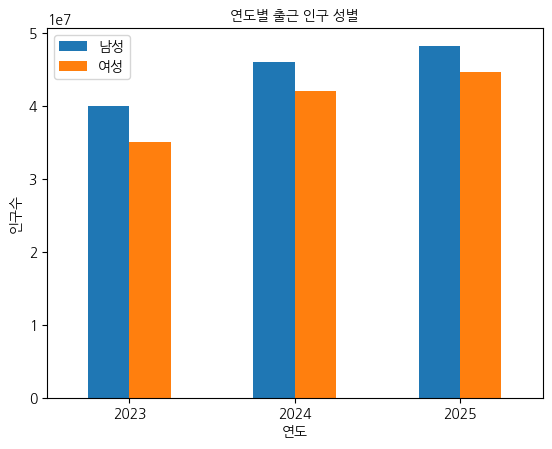

In [55]:
age_month = df_work.groupby(["year", "month", "AGE_GRP"])["CNT"].sum().unstack()
print(age_month.head())

plt.figure()
gender_year.plot(kind="bar")

plt.title("연도별 출근 인구 성별", fontproperties=fontprop)
plt.xlabel("연도", fontproperties=fontprop)
plt.ylabel("인구수", fontproperties=fontprop)

plt.xticks(rotation=0, fontproperties=fontprop)
plt.legend(prop=fontprop)

plt.show()

<Figure size 640x480 with 0 Axes>

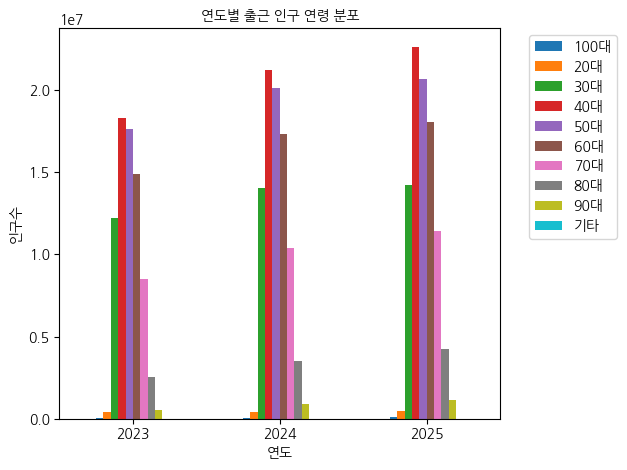

In [58]:
plt.figure()

age_year.plot(kind="bar")

plt.title("연도별 출근 인구 연령 분포", fontproperties=fontprop)
plt.xlabel("연도", fontproperties=fontprop)
plt.ylabel("인구수", fontproperties=fontprop)

plt.xticks(rotation=0, fontproperties=fontprop)

plt.legend(prop=fontprop, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

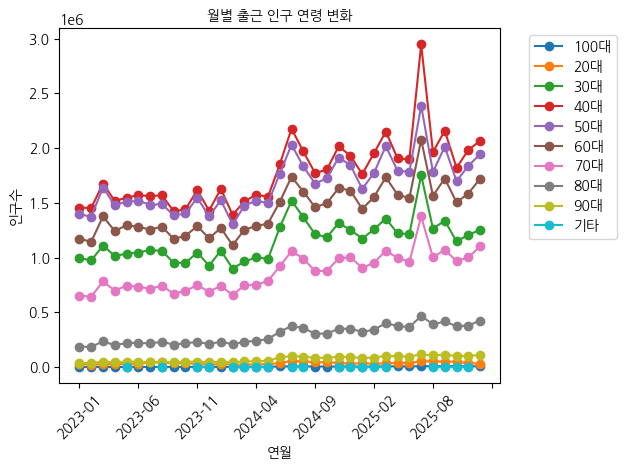

In [61]:
# 1. 출근 데이터 필터링
df_all["PURPOSE"] = df_all["PURPOSE"].astype(int)
df_work = df_all[df_all["PURPOSE"] == 1].copy()


# 2. 연도 / 월 생성
df_work["ETL_YM"] = df_work["ETL_YM"].astype(str)
df_work["year"] = df_work["ETL_YM"].str[:4]
df_work["month"] = df_work["ETL_YM"].str[4:6]

df_work["year_month"] = df_work["year"] + "-" + df_work["month"]


# 3. 성별 정리
df_work["SEX_CD"] = df_work["SEX_CD"].replace({
    "M": "남성",
    "W": "여성",
    "F": "여성"
})


# 4. 연령 변환
age_map = {
    1: "10대",
    2: "20대",
    3: "30대",
    4: "40대",
    5: "50대",
    6: "60대",
    7: "70대",
    8: "80대",
    9: "90대",
    10: "100대",
    11: "기타"
}

df_work["AGE_GRP"] = df_work["AGE_GRP"].map(age_map)


# 5. 월별 연령 트렌드
trend_month = df_work.groupby(["year_month", "AGE_GRP"])["CNT"].sum().unstack()

# 정렬 (중요)
trend_month = trend_month.sort_index()


# 6. 그래프
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

trend_month.plot(marker="o")

plt.title("월별 출근 인구 연령 변화", fontproperties=fontprop)
plt.xlabel("연월", fontproperties=fontprop)
plt.ylabel("인구수", fontproperties=fontprop)

plt.xticks(rotation=45, fontproperties=fontprop)

plt.legend(prop=fontprop, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()